In [2]:
# -*- coding: utf-8 -*-
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
from scipy.interpolate import interp1d

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 200
plt.rcParams.update({"font.size": 11, "legend.fontsize": 10})

G = 1  # kpc (km/s)^2 / Msun

# ---------------------------------------------------------------------
# Helper: infer method and level from filename
# ---------------------------------------------------------------------
def infer_method_and_level(label):
    base = os.path.basename(label).lower()
    if "fmm" in base:
        method = "FMM"
        m = re.search(r"fmm[_\-]?(\d+)", base)
        lvl = int(m.group(1)) if m else None
    elif "mg" in base:
        method = "MG"
        lvl = None
    else:
        method = "unknown"
        lvl = None
    return method, lvl

# ---------------------------------------------------------------------
# Load direct potential from TXT
# ---------------------------------------------------------------------
def load_direct_phi(txt_file="./txt/direct_phi_xslice.txt"):
    data = np.loadtxt(txt_file)
    x_eval = data[:, 0]
    phi_eval = data[:, 1]
    return x_eval, phi_eval

# ---------------------------------------------------------------------
# Helper: regime boundaries
# ---------------------------------------------------------------------
def regime_boundaries(levelmin, level_amr_to_fmm, method, box_length=1.0, log_file=None, dx_round=True, n_far_levels=5):
    dx = box_length / (2 ** levelmin)
    r_direct = r_intermediate = None

    if log_file and os.path.exists(log_file):
        txt = open(log_file).read()
        m_direct = re.search(r"r_fmm_direct_max\s*=\s*([0-9.eE+-]+)", txt)
        m_inter = re.search(r"r_fmm_intermediate_max\s*=\s*([0-9.eE+-]+)", txt)
        if m_direct: r_direct = float(m_direct.group(1))
        if m_inter: r_intermediate = float(m_inter.group(1))

    if method.lower() == "fmm" and level_amr_to_fmm is not None:
        l_box = (2 ** level_amr_to_fmm) * dx
        if r_direct is None: r_direct = 2.0 * l_box
        if r_intermediate is None: r_intermediate = 4.0 * l_box

    if dx_round and dx > 0:
        if r_direct is not None:
            pix = max(1, round(r_direct / dx))
            r_direct = pix * dx
        if r_intermediate is not None:
            pix = max(int(np.ceil(r_direct / dx)) + 1 if r_direct else 2, round(r_intermediate / dx))
            r_intermediate = pix * dx

    far_bounds = []
    if r_intermediate is not None:
        prev = r_intermediate
        for i in range(n_far_levels):
            nxt = prev * 2.0
            far_bounds.append((prev, nxt))
            prev = nxt

    return r_direct, r_intermediate, far_bounds

# ---------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------
def load_data(filename1, filename2, out_dir="../out"):
    names = ["x", "y", "z", "fx", "fy", "fz", "phi"]
    file1 = os.path.join(out_dir, filename1)
    file2 = os.path.join(out_dir, filename2)

    df1 = pd.read_csv(file1, header=None, sep=r"\s+", names=names)
    df2 = pd.read_csv(file2, header=None, sep=r"\s+", names=names)

    for df in [df1, df2]:
        df["x"] -= df["x"].min()
        df["y"] -= df["y"].min()
        df["z"] -= df["z"].min()

    return df1, df2, filename1, filename2

# ---------------------------------------------------------------------
# 2D comparison plot
# ---------------------------------------------------------------------
def plot_2d(df1, df2, label1, label2, z_slice, boxsize=1.0):
    df1_slice = df1[np.isclose(df1["z"], z_slice)]
    df2_slice = df2[np.isclose(df2["z"], z_slice)]

    grid1 = df1_slice.pivot(index="y", columns="x", values="phi")
    grid2 = df2_slice.pivot(index="y", columns="x", values="phi")

    # Physical coordinate extent
    extent = [0, boxsize, 0, boxsize]

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    im0 = axs[0].imshow(
        grid1.values,
        origin="lower",
        cmap="viridis",
        extent=extent,
        aspect="equal"
    )
    axs[0].set_title(f"{label1}")
    axs[0].set_xlabel(r"$x\,[\mathrm{kpc}/h]$")
    axs[0].set_ylabel(r"$y\,[\mathrm{kpc}/h]$")
    plt.colorbar(im0, ax=axs[0])

    im1 = axs[1].imshow(
        grid2.values,
        origin="lower",
        cmap="viridis",
        extent=extent,
        aspect="equal"
    )
    axs[1].set_title(f"{label2}  (z={z_slice})")
    axs[1].set_xlabel("x")
    axs[1].set_ylabel("y")
    plt.colorbar(im1, ax=axs[1])

    diff = grid2.values - grid1.values
    with np.errstate(divide="ignore", invalid="ignore"):
        rel_diff = np.where(grid1.values != 0, diff / grid1.values, 0)

    im2 = axs[2].imshow(
        rel_diff,
        origin="lower",
        cmap="coolwarm",
        extent=extent,
        aspect="equal"
    )
    axs[2].set_title("Relative Difference")
    axs[2].set_xlabel(r"$x\,[\mathrm{kpc}/h]$")
    axs[2].set_ylabel(r"$y\,[\mathrm{kpc}/h]$")
    plt.colorbar(im2, ax=axs[2])

    plt.tight_layout()
    os.makedirs("./fig", exist_ok=True)
    plt.savefig(f"./fig/compare_2d_{z_slice}_{label1}_vs_{label2}.pdf", dpi=200)
    plt.show()

# ---------------------------------------------------------------------
# Radial profile plot using direct potential
# ---------------------------------------------------------------------
def plot_profile(df1, df2, label1, label2, z_slice,
                 levelmin=7, level_amr_to_fmm=None,
                 box_length=1.0, n_far_levels=5, mode="x",name=None):

    df1_slice = df1[np.isclose(df1["z"], z_slice)]
    df2_slice = df2[np.isclose(df2["z"], z_slice)]
    grid1 = df1_slice.pivot(index="y", columns="x", values="phi").values
    grid2 = df2_slice.pivot(index="y", columns="x", values="phi").values
    nx, ny = grid1.shape
    dx = box_length / (2 ** levelmin)
    xc_phys = box_length / 2.0
    yc_phys = box_length / 2.0
    zc_phys = (z_slice + 0.5) * dx

    if mode == "x":
        yc_idx = ny // 2
        x_phys = (np.arange(nx) + 0.5) * dx
        vals1_row = grid1[yc_idx, :]
        vals2_row = grid2[yc_idx, :]

        # 🔹 only take right side: x > midpoint (~63 for 128 grid)
        mid_idx = nx // 2
        x_phys = x_phys[mid_idx:]
        vals1_row = vals1_row[mid_idx:]
        vals2_row = vals2_row[mid_idx:]

        # distances from center for radial fit
        r_fit = np.abs(x_phys - xc_phys)

    elif mode == "diag":
        n_steps = min(nx, ny)
        x_idx = np.arange(n_steps)
        y_idx = np.arange(n_steps)
        vals1_row = np.array([grid1[y, x] for x, y in zip(x_idx, y_idx)])
        vals2_row = np.array([grid2[y, x] for x, y in zip(x_idx, y_idx)])
        x_phys = (x_idx + 0.5) * dx
        y_phys = (y_idx + 0.5) * dx
        r_fit = np.sqrt((x_phys - xc_phys)**2 + (y_phys - yc_phys)**2)
    elif mode == "-x":
        # mirror of 'x' mode: use the LEFT half: x < midpoint
        yc_idx = ny // 2
        x_phys = (np.arange(nx) + 0.5) * dx
        vals1_row = grid1[yc_idx, :]
        vals2_row = grid2[yc_idx, :]

        mid_idx = nx // 2

        # keep left half
        x_phys = x_phys[:mid_idx]
        vals1_row = vals1_row[:mid_idx]
        vals2_row = vals2_row[:mid_idx]

        # distances from center
        r_fit = np.abs(x_phys - xc_phys)
    else:
        raise ValueError("mode must be 'x' or 'diag'")

        # --------------------------------------------------------
    # Decide analytic reference: NFW vs single point vs spheres
    # --------------------------------------------------------
    has_nfw    = "nfw" in label1.lower() or "nfw" in label2.lower()
    has_single = "single" in label1.lower() or "single" in label2.lower()
    has_spheres = "spheres" in label1.lower() or "spheres" in label2.lower()

    # inconsistent
    assert sum([has_nfw, has_single, has_spheres]) <= 1, \
        f"Inconsistent analytic reference: labels={label1}, {label2}"

    if has_nfw:
        x_direct, phi_direct = load_direct_phi(f"./txt/direct_phi_xslice_lvl{levelmin+1}.txt")
        phi_interp = interp1d(x_direct, phi_direct, bounds_error=False, fill_value="extrapolate")
        phi_nfw = phi_interp(r_fit)
        analytic_label = "NFW analytic"

    elif has_single:
        # point mass at center
        phi_nfw = -1 / r_fit
        analytic_label = "Analytic -1/r"

    elif has_spheres and "lv8" in label1.lower():
        # --------------------------------------------------------
        # Analytic potential of two uniform-density spheres, rho=1
        # radii R1=0.1, R2=0.3
        # centers x1=0.2, x2=0.7, both at y=z=0
        # --------------------------------------------------------
        rho = 1.0
        R1, R2 = 0.1, 0.2
        x1, x2 = 0.2, 0.7
        y1 = y2 = 0.5
        z1 = z2 = 0.5

        # masses
        M1 = (4/3)*np.pi*R1**3*rho
        M2 = (4/3)*np.pi*R2**3*rho

        def phi_sphere(r, R, M):
            """analytic uniform-density sphere potential"""
            phi_out = -G*M / r
            phi_in  = -1.5*G*M/R + 0.5*G*M*r*r/(R**3)
            return np.where(r >= R, phi_out, phi_in)

        # coordinate: slice at y=z=0 so r is |x - xc|
        r1 = np.abs(x_phys - x1)
        r2 = np.abs(x_phys - x2)

        phi_total = phi_sphere(r1, R1, M1) + phi_sphere(r2, R2, M2)

        phi_nfw = phi_total
        analytic_label = "Analytic 2-sphere solution"
    elif has_spheres and "lv9" in label1.lower():
        # --------------------------------------------------------
        # Analytic potential of two uniform-density spheres, rho=1
        # radii R1=0.1, R2=0.3
        # centers x1=0.2, x2=0.7, both at y=z=0
        # --------------------------------------------------------
        rho = 1.0
        R1, R2 = 0.1, 0.2
        x1, x2 = 0.7, 1.2
        y1 = y2 = 1.0
        z1 = z2 = 1.0

        # masses
        M1 = (4/3)*np.pi*R1**3*rho
        M2 = (4/3)*np.pi*R2**3*rho

        def phi_sphere(r, R, M):
            """analytic uniform-density sphere potential"""
            phi_out = -G*M / r
            phi_in  = -1.5*G*M/R + 0.5*G*M*r*r/(R**3)
            return np.where(r >= R, phi_out, phi_in)

        # coordinate: slice at y=z=0 so r is |x - xc|
        r1 = np.abs(x_phys - x1)
        r2 = np.abs(x_phys - x2)

        phi_total = phi_sphere(r1, R1, M1) + phi_sphere(r2, R2, M2)

        phi_nfw = phi_total
        analytic_label = "Analytic 2-sphere solution"

    else:
        phi_nfw = None
        analytic_label = None


    # residuals
    with np.errstate(divide="ignore", invalid="ignore"):
        if phi_nfw is not None:
            resid1 = (vals1_row - phi_nfw) / phi_nfw
            resid2 = (vals2_row - phi_nfw) / phi_nfw
        else:
            resid1 = (vals1_row + 1 / r_fit) / (-1 / r_fit)
            resid2 = (vals2_row + 1 / r_fit) / (-1 / r_fit)

    resid_pct1 = 100 * resid1
    resid_pct2 = 100 * resid2
    resid_abs1 = np.abs(resid1)
    resid_abs2 = np.abs(resid2)

    # regimes
    method1, lvl1 = infer_method_and_level(label1)
    method2, lvl2 = infer_method_and_level(label2)
    lvl1_use = level_amr_to_fmm if (level_amr_to_fmm is not None and method1=="fmm") else lvl1
    lvl2_use = level_amr_to_fmm if (level_amr_to_fmm is not None and method2=="fmm") else lvl2
    log1 = label1.replace(".out", ".log")
    log2 = label2.replace(".out", ".log")
    r_direct1, r_inter1, far1 = regime_boundaries(levelmin, lvl1_use, method1, box_length, log1, n_far_levels=n_far_levels)
    r_direct2, r_inter2, far2 = regime_boundaries(levelmin, lvl2_use, method2, box_length, log2, n_far_levels=n_far_levels)

    label1 = method1
    label2 = method2
    if method1 == "FMM":
        label1 += f"-{level_amr_to_fmm}"
    if method2 == "FMM":
        label2 += f"-{level_amr_to_fmm}"
        
    if mode=='diag':
        try:
            r_direct1, r_inter1 = r_direct1 * np.sqrt(3), r_inter1 * np.sqrt(3)
            r_direct2, r_inter2 = r_direct2 * np.sqrt(3), r_inter2 * np.sqrt(3)
        except:
            pass

    # --------------------------------------------------------
    # Plotting with improved style
    # --------------------------------------------------------
    fig, (ax1, ax2, ax3) = plt.subplots(
        3, 1, figsize=(4.5, 6.5),
        gridspec_kw={"height_ratios": [3, 1, 1]},
        sharex=True
    )

    # ---------------------------
    # (1) Potential profiles
    # ---------------------------
    ax1.loglog(r_fit, np.abs(vals1_row), "o", ms=3, alpha=0.6, label=label1, color="tab:blue")
    ax1.loglog(r_fit, np.abs(vals2_row), "o", ms=3, alpha=0.6, label=label2, color="tab:orange")
          
    if phi_nfw is not None:
        ax1.loglog(r_fit, np.abs(phi_nfw), "k--", lw=1.2, label=analytic_label)

    ax1.set_ylabel(r"$|\Phi|$")
    ax1.legend(loc="best", frameon=False)
    ax1.grid(True, which="both", ls="--", lw=0.4, alpha=0.3)

    # --- Regime shading ---
    def shade_regime(ax, r_d, r_i, far, color):
        if r_d:
            ax.axvline(r_d, color=color, lw=1.2, ls="--", alpha=0.6)
        if r_i:
            ax.axvline(r_i, color=color, lw=1.2, ls=":", alpha=0.6)
        for i, (rmin, rmax) in enumerate(far[:3]):  # only show first few far levels
            ax.axvspan(rmin, rmax, color=color, alpha=0.05 * (3 - i), lw=0)

    shade_regime(ax1, r_direct1, r_inter1, far1, "tab:blue")
    shade_regime(ax1, r_direct2, r_inter2, far2, "tab:orange")

    # ---------------------------
    # (2) Percent residual
    # ---------------------------
    ax2.plot(r_fit, resid_pct1, color="tab:blue", lw=0.8, alpha=0.8, label=f"{label1}")
    ax2.plot(r_fit, resid_pct2, color="tab:orange", lw=0.8, alpha=0.8, label=f"{label2}")
    ax2.axhline(0, color="k", lw=0.8, alpha=0.7)

    ax2.set_xscale("log")
    ax2.set_ylabel("Residual [%]")
    ax2.legend(loc="lower left", frameon=False)
    ax2.grid(True, which="both", ls="--", lw=0.4, alpha=0.3)
    ax2.set_ylim(-10, 2)

    # reuse regime lines for consistency
    shade_regime(ax2, r_direct1, r_inter1, far1, "tab:blue")
    shade_regime(ax2, r_direct2, r_inter2, far2, "tab:orange")

    # ---------------------------
    # (3) Log absolute residual
    # ---------------------------
    ax3.semilogx(r_fit, np.log10(resid_abs1 + 1e-12), color="tab:blue", lw=0.8, label=f"{label1}")
    ax3.semilogx(r_fit, np.log10(resid_abs2 + 1e-12), color="tab:orange", lw=0.8, label=f"{label2}")
    ax3.set_xlabel("r")
    ax3.set_ylabel(r"$\log_{10}|\mathrm{Residual}|$")
    ax3.legend(loc="lower left", frameon=False)
    ax3.grid(True, which="both", ls="--", lw=0.4, alpha=0.3)

    shade_regime(ax3, r_direct1, r_inter1, far1, "tab:blue")
    shade_regime(ax3, r_direct2, r_inter2, far2, "tab:orange")

    # ---------------------------
    plt.tight_layout(h_pad=0.5)
    os.makedirs("./fig", exist_ok=True)
    safe1 = os.path.splitext(os.path.basename(label1))[0]
    safe2 = os.path.splitext(os.path.basename(label2))[0]
    plt.savefig(f"./fig/profile_{name}_{safe1}_vs_{safe2}_{mode}.pdf", dpi=250, bbox_inches="tight")
    plt.show()



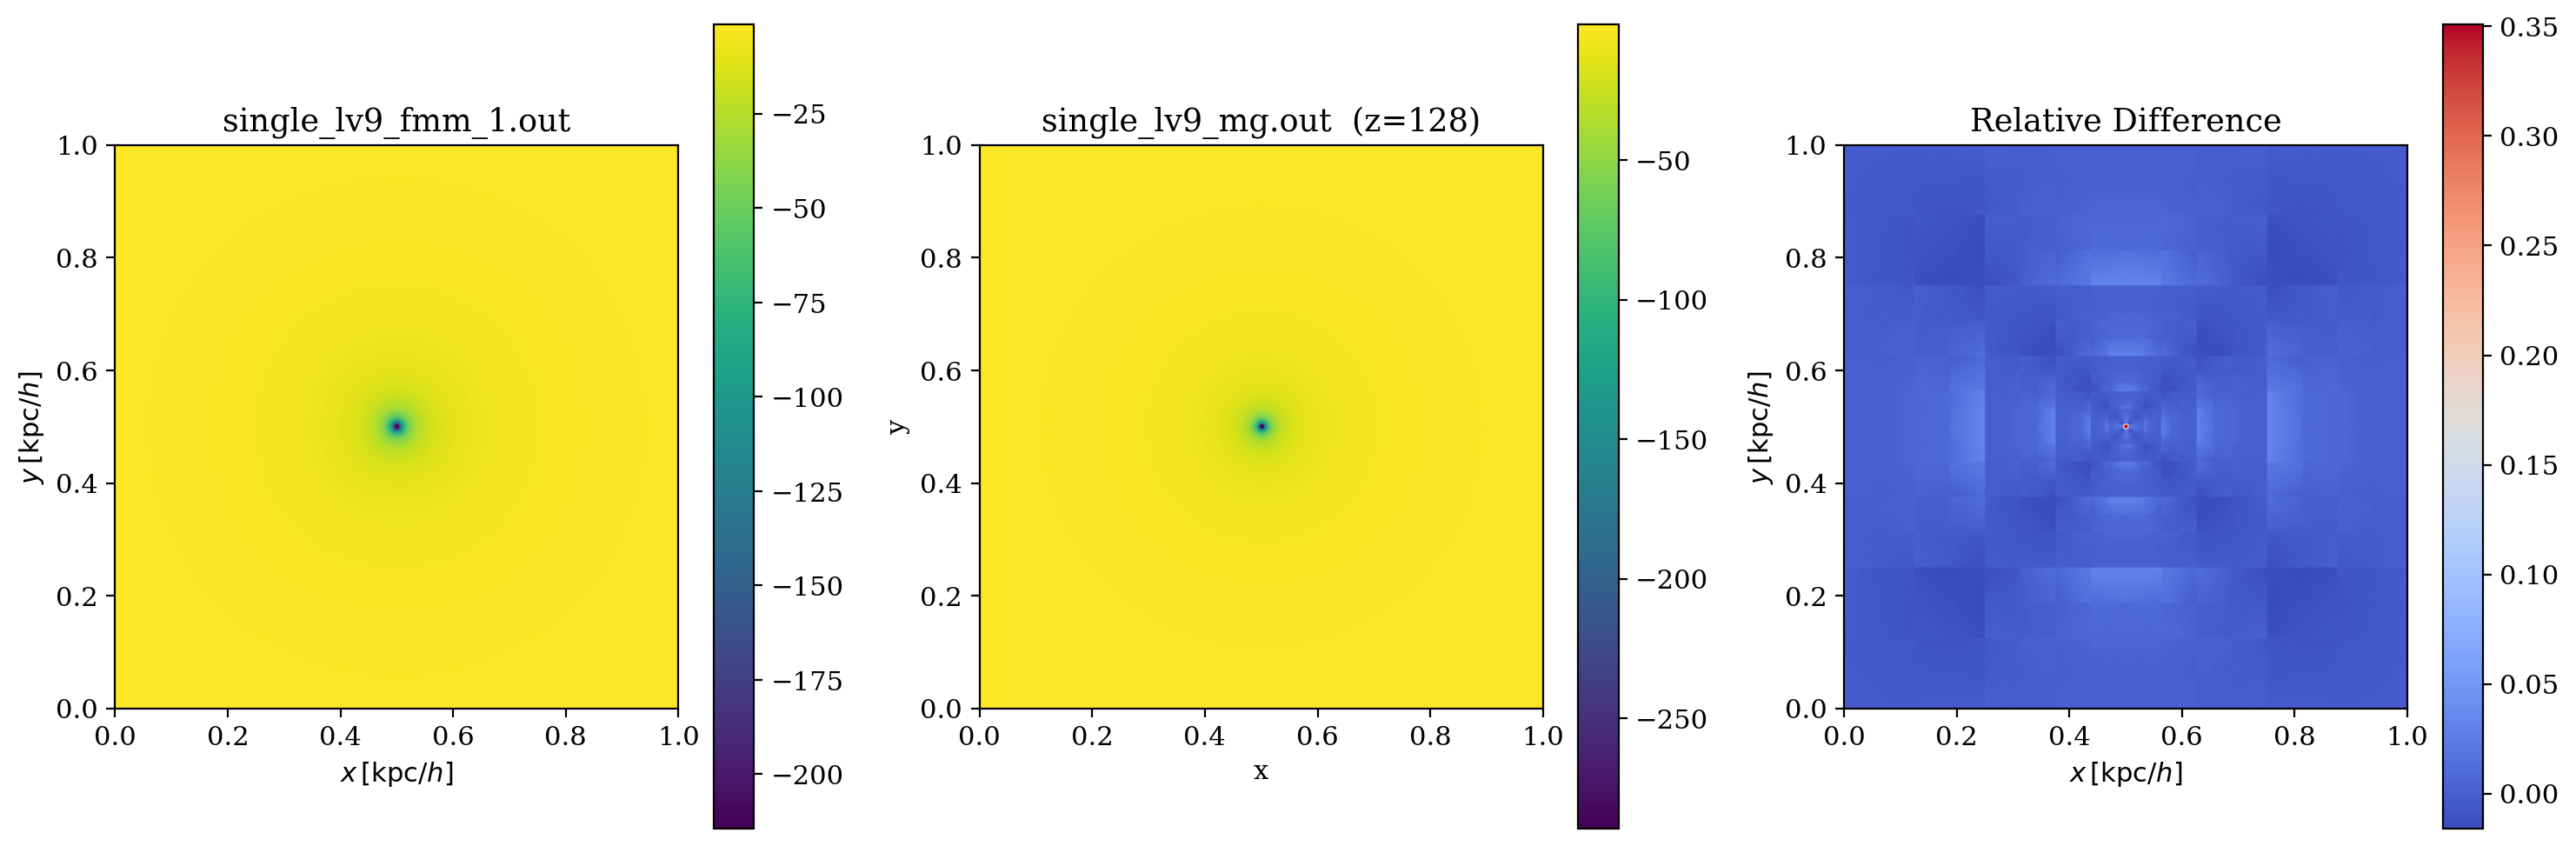

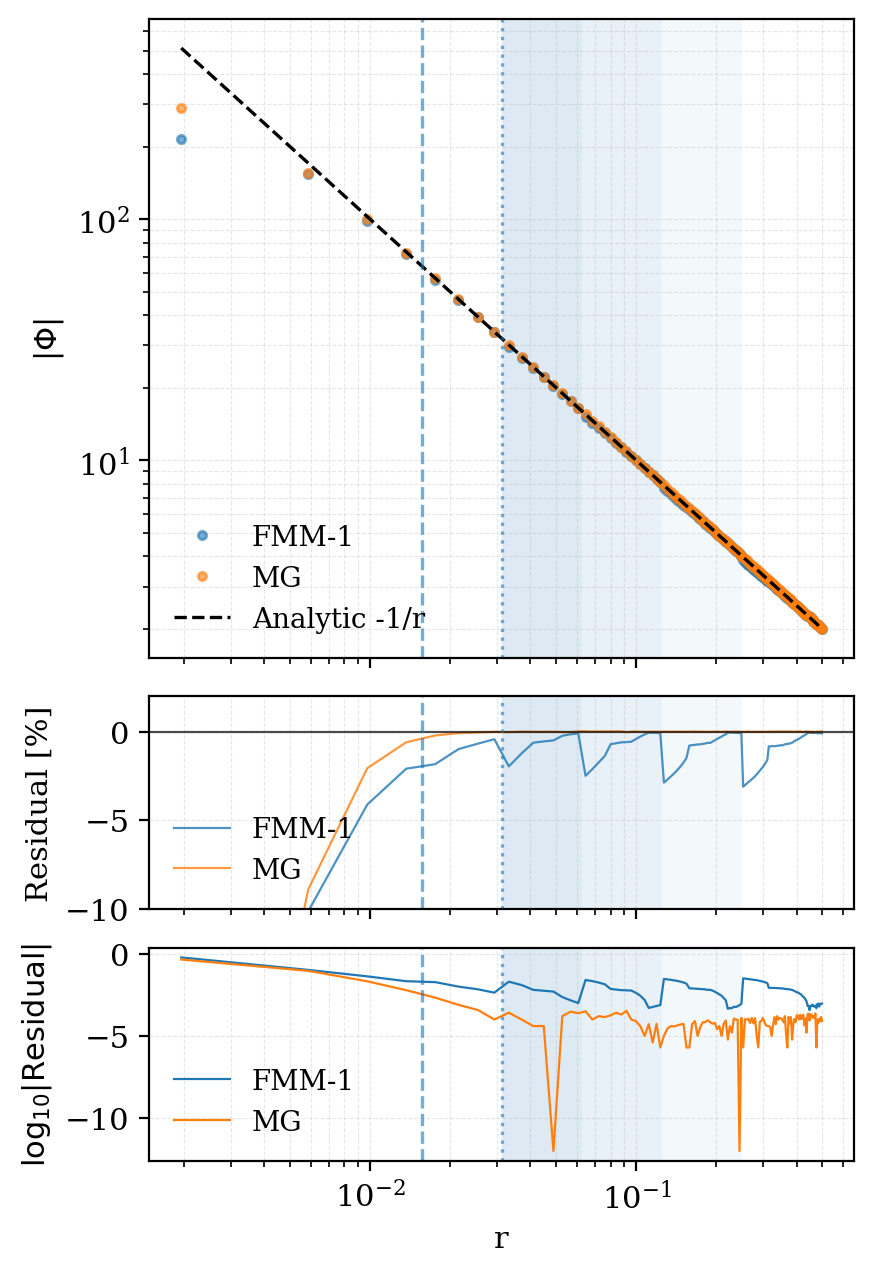

In [3]:
file1 = "single_lv9_fmm_1.out"
file2 = "single_lv9_mg.out"  # if filename contains "nfw", overlay NFW analytic
z_slice = 128
df1, df2, label1, label2 = load_data(file1, file2)
#label1 = 'FMM-1'
#label2 = 'MG'

plot_2d(df1, df2, label1, label2, z_slice)
# x-direction profile
plot_profile(df1, df2, label1, label2, z_slice, levelmin=8, box_length=1, level_amr_to_fmm=1, mode="x", name='single')

            x    y    z     fx     fy     fz       phi
11051632  128  128  128 -877.3 -859.7 -845.4 -130300.0


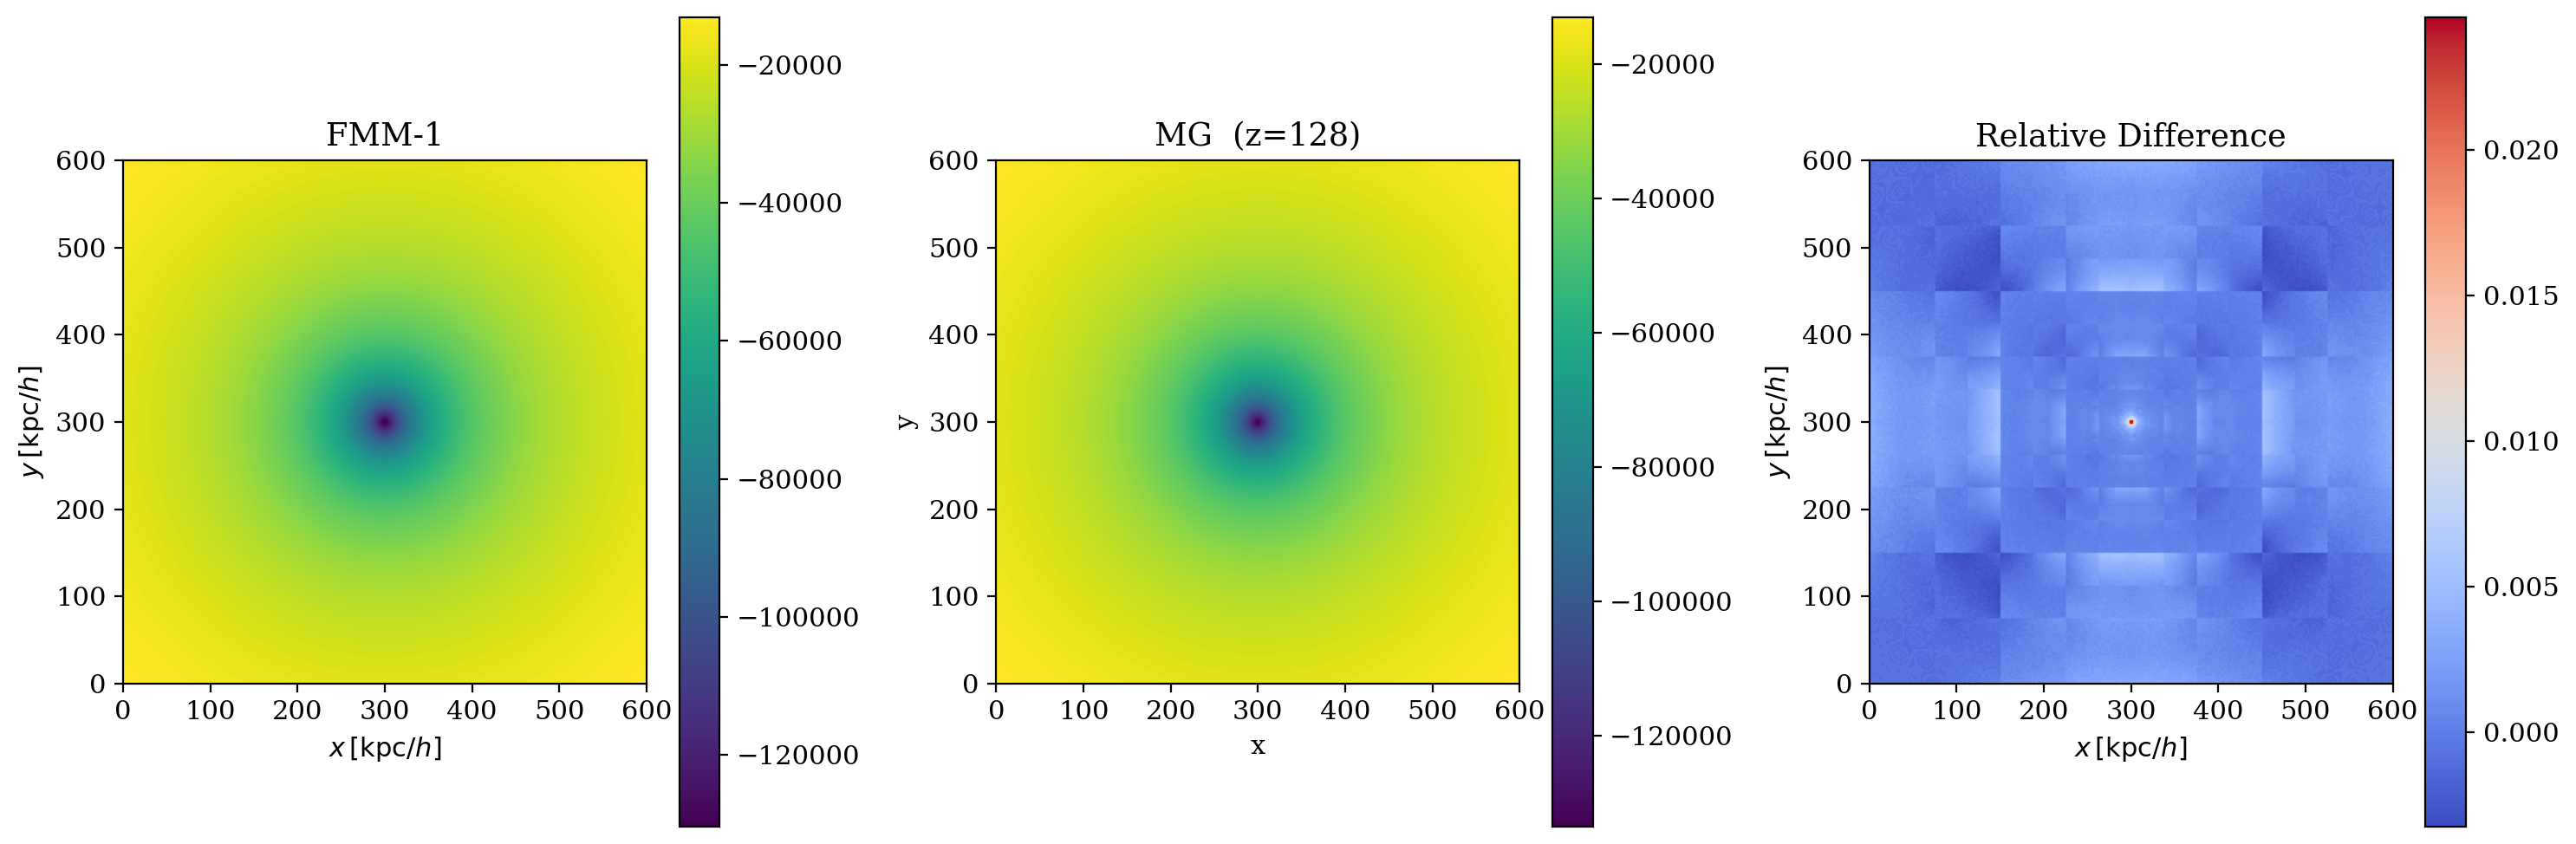

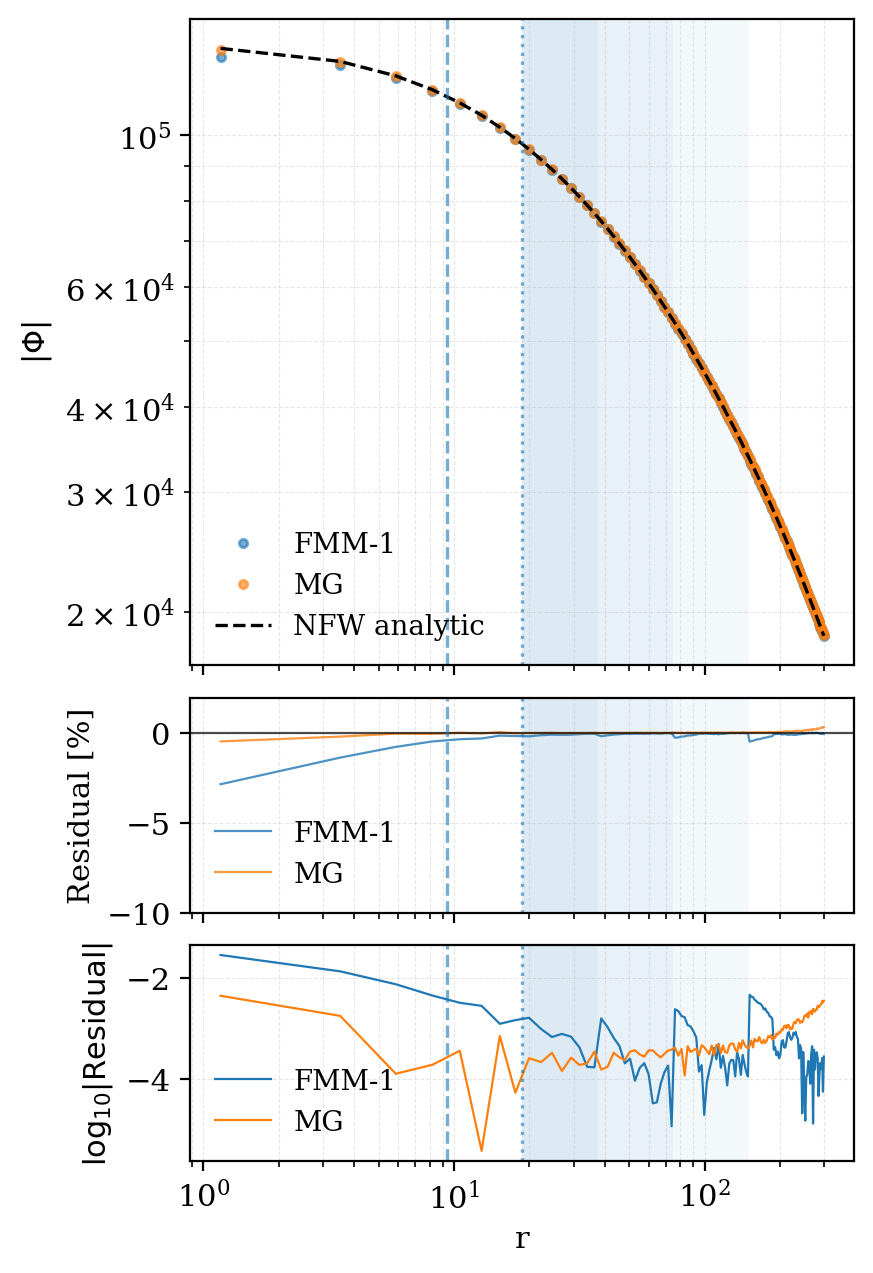

In [4]:
file1 = "nfw_lv9_fmm_1.out"
file2 = "nfw_lv9_mg.out"  
z_slice = 128
df1, df2, label1, label2 = load_data(file1, file2)
print(df1[(df1["x"] == 128) & (df1["y"] == 128) & (df1["z"] == 128)])

plot_2d(df1, df2, 'FMM-1', 'MG', z_slice, boxsize=600)
# x-direction profile
plot_profile(df1, df2, label1, label2, z_slice, levelmin=8, box_length=600, level_amr_to_fmm=1, mode="x",name='nfw')

Using 1977324 particles inside box
Using fixed center: (0.000000, 0.000000, 0.000000)
Fitted NFW parameters:
  rho_s = 3.876087e+01
  r_s   = 1.809544e+01
  C     = 2.757851e+04
Saved fit plot to ./fig/fitted_nfw_profile_lvl9.pdf


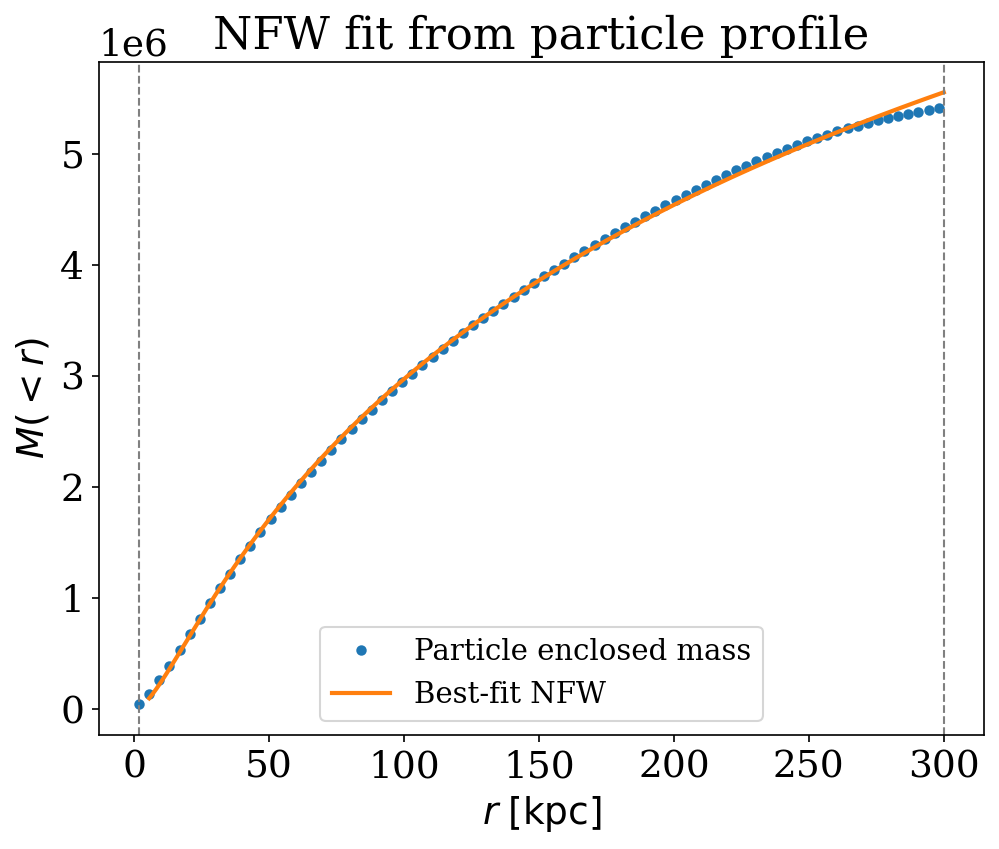

Saved residual plot to ./fig/fitted_nfw_profile_residual_lvl9.pdf


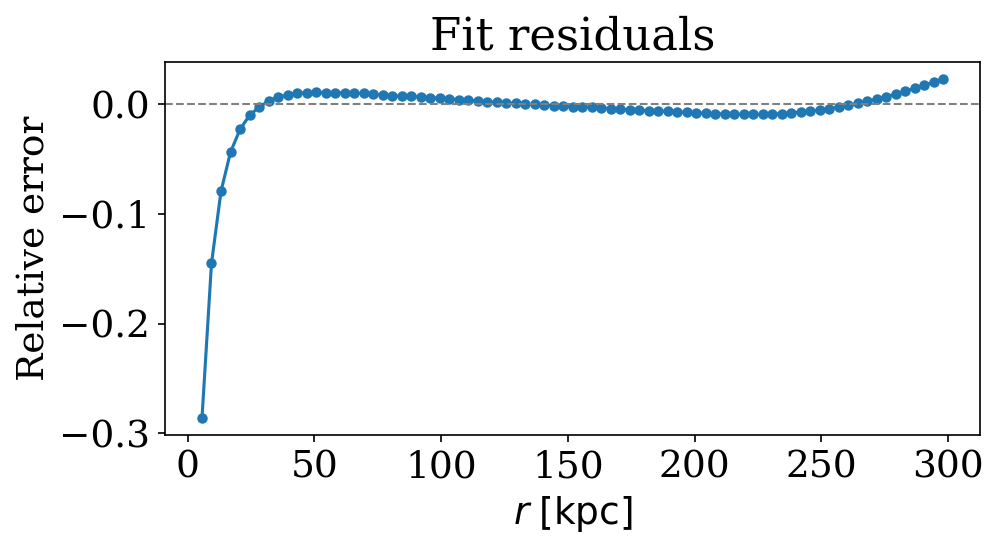

Mean |rel err| in fit range: 1.357e-02
Max  |rel err| in fit range: 2.860e-01
Saved fitted analytic NFW slice to ./txt/fitted_nfw_phi_slice_lvl9_zcell0.txt


In [12]:
# -*- coding: utf-8 -*-
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 150
plt.rcParams.update({
    "font.size": 18,
    "legend.fontsize": 14,
})

# -------------------------------
# Parameters
# -------------------------------
ic_file = "../nfw/ic_part"   # columns: x y z vx vy vz m
box_cut = 300.0              # kpc, cube: [-box_cut, box_cut]^3
G = 1.0                      # kpc (km/s)^2 / Msun
lvl = 9
z_cell = 0

# radial fitting setup
nbins = 80
rmin_fit = 2.0
rmax_fit = 300.0

# -------------------------------
# NFW helpers
# -------------------------------
def nfw_mass_enclosed(r, rho_s, r_s):
    x = r / r_s
    return 4.0 * np.pi * rho_s * r_s**3 * (np.log(1.0 + x) - x / (1.0 + x))

def nfw_phi(r, rho_s, r_s, C):
    r_safe = np.maximum(r, 1e-12)
    x = r_safe / r_s
    return -4.0 * np.pi * G * rho_s * r_s**3 * np.log(1.0 + x) / r_safe + C

# -------------------------------
# Load particle data
# -------------------------------
data = np.loadtxt(ic_file)
x, y, z, vx, vy, vz, m = data.T

mask = (
    (x >= -box_cut) & (x <= box_cut) &
    (y >= -box_cut) & (y <= box_cut) &
    (z >= -box_cut) & (z <= box_cut)
)

x = x[mask]
y = y[mask]
z = z[mask]
m = m[mask]

print(f"Using {len(m)} particles inside box")

# -------------------------------
# Use the same center as the solver grid
# -------------------------------
xc = yc = zc = 0.0

print(f"Using fixed center: ({xc:.6f}, {yc:.6f}, {zc:.6f})")

# -------------------------------
# Build enclosed-mass profile
# -------------------------------
r = np.sqrt((x - xc)**2 + (y - yc)**2 + (z - zc)**2)

bins = np.linspace(0.0, box_cut, nbins + 1)
r_edges_left = bins[:-1]
r_edges_right = bins[1:]
r_centers = 0.5 * (r_edges_left + r_edges_right)

mass_shell = np.zeros(nbins)
for i in range(nbins):
    sel = (r >= r_edges_left[i]) & (r < r_edges_right[i])
    mass_shell[i] = np.sum(m[sel])

mass_enc = np.cumsum(mass_shell)

# -------------------------------
# Fit NFW enclosed mass
# -------------------------------
fit_mask = (
    (r_centers >= rmin_fit) &
    (r_centers <= rmax_fit) &
    (mass_enc > 0.0)
)

r_fit = r_centers[fit_mask]
m_fit = mass_enc[fit_mask]

rs0 = 0.1 * box_cut
rho0 = mtot / (4.0 * np.pi * rs0**3)

popt, _ = curve_fit(
    nfw_mass_enclosed,
    r_fit,
    m_fit,
    p0=[rho0, rs0],
    bounds=(0.0, np.inf),
    maxfev=20000
)

rho_s_fit, r_s_fit = popt

print("Fitted NFW parameters:")
print(f"  rho_s = {rho_s_fit:.6e}")
print(f"  r_s   = {r_s_fit:.6e}")

# additive constant so phi(box_cut)=0
C_fit = -nfw_phi(np.array([box_cut]), rho_s_fit, r_s_fit, 0.0)[0]
print(f"  C     = {C_fit:.6e}")

# -------------------------------
# Plot fit quality
# -------------------------------
os.makedirs("./fig", exist_ok=True)

r_plot = np.linspace(max(1e-3, r_centers[1]), box_cut, 1000)
m_model = nfw_mass_enclosed(r_plot, rho_s_fit, r_s_fit)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(r_centers, mass_enc, "o", ms=4, label="Particle enclosed mass")
ax.plot(r_plot, m_model, "-", lw=2, label="Best-fit NFW")
ax.axvline(rmin_fit, ls="--", lw=1, color="gray")
ax.axvline(rmax_fit, ls="--", lw=1, color="gray")
ax.set_xlabel(r"$r\;[\mathrm{kpc}]$")
ax.set_ylabel(r"$M(<r)$")
ax.set_title("NFW fit from particle profile")
ax.legend()
fig.tight_layout()

fit_plot_file = f"./fig/fitted_nfw_profile_lvl{lvl}.pdf"
plt.savefig(fit_plot_file, bbox_inches="tight")
print(f"Saved fit plot to {fit_plot_file}")
plt.show()

# optional residual plot
m_data_interp = mass_enc[fit_mask]
m_model_fit = nfw_mass_enclosed(r_fit, rho_s_fit, r_s_fit)
rel_err = (m_model_fit - m_data_interp) / np.maximum(m_data_interp, 1e-30)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(r_fit, rel_err, "o-", ms=4)
ax.axhline(0.0, ls="--", lw=1, color="gray")
ax.set_xlabel(r"$r\;[\mathrm{kpc}]$")
ax.set_ylabel("Relative error")
ax.set_title("Fit residuals")
fig.tight_layout()

resid_plot_file = f"./fig/fitted_nfw_profile_residual_lvl{lvl}.pdf"
plt.savefig(resid_plot_file, bbox_inches="tight")
print(f"Saved residual plot to {resid_plot_file}")
plt.show()

print(f"Mean |rel err| in fit range: {np.mean(np.abs(rel_err)):.3e}")
print(f"Max  |rel err| in fit range: {np.max(np.abs(rel_err)):.3e}")

# -------------------------------
# Build analytic slice from fitted NFW
# -------------------------------
n_points = 2**(lvl - 1)
N_cells = n_points

dx_cell = 2 * box_cut / N_cells
x_eval_phys = -box_cut + (np.arange(n_points) + 0.5) * dx_cell
y_eval_phys = -box_cut + (np.arange(n_points) + 0.5) * dx_cell
z_eval_phys = dx_cell / 2.0

X, Y = np.meshgrid(x_eval_phys, y_eval_phys, indexing="ij")
R = np.sqrt((X - xc)**2 + (Y - yc)**2 + (z_eval_phys - zc)**2)

phi_eval = nfw_phi(R, rho_s_fit, r_s_fit, C_fit)

# -------------------------------
# Save fitted analytic slice
# -------------------------------
os.makedirs("./txt", exist_ok=True)
out_file = f"./txt/fitted_nfw_phi_slice_lvl{lvl}_zcell{z_cell}.txt"

np.savetxt(
    out_file,
    np.column_stack([X.ravel(), Y.ravel(), phi_eval.ravel()]),
    header="x[kpc]  y[kpc]  phi[kpc (km/s)^2]",
    fmt="%.6e"
)

print(f"Saved fitted analytic NFW slice to {out_file}")

Using 1977324 particles inside box
M200 = 5.535163e+06
c    = 1.000000e+01
R200 = 2.054790e+02
rs   = 2.054790e+01
Saved analytic NFW slice to ./txt/analytic_nfw_phi_slice_lvl9_zcell128.txt
Saved analytic plot to ./fig/analytic_nfw_phi_slice_lvl9_zcell128.pdf


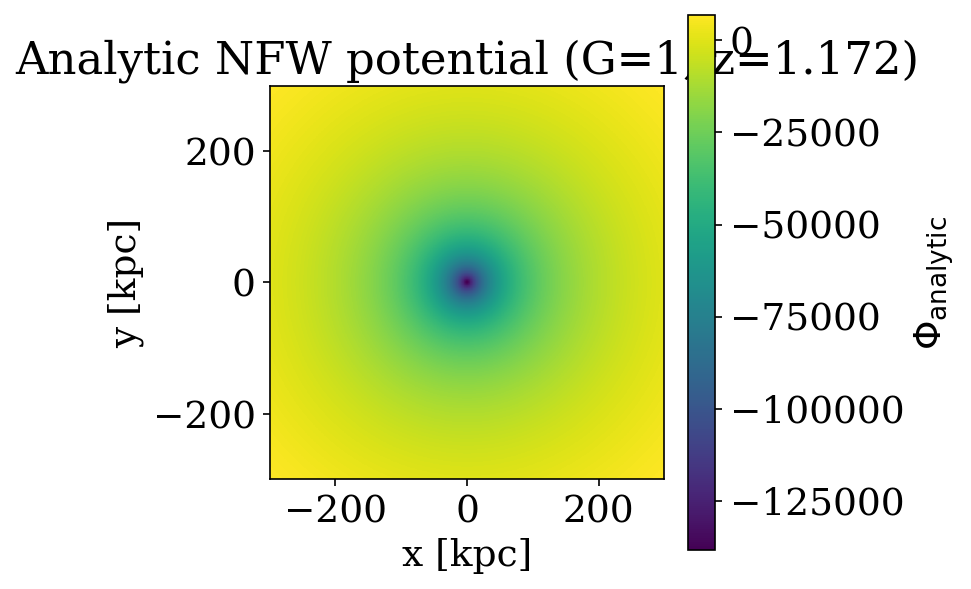

In [16]:
# -*- coding: utf-8 -*-
import numpy as np
import os
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 150
plt.rcParams.update({
    "font.size": 18,
    "legend.fontsize": 14,
})

# -------------------------------
# Parameters
# -------------------------------
ic_file = "../nfw/ic_part"   # columns: x y z vx vy vz m
box_cut = 300.0              # kpc, box runs from -box_cut to +box_cut
G = 1.0
lvl = 9
z_cell = 128                 # use 128 for the central slice when lvl=9
c = 10.0
R200 = 205.479               # same length units as particle file

# -------------------------------
# NFW helper
# -------------------------------
def nfw_phi_G1_from_M200(r, M200, c, R200, C=0.0):
    r_safe = np.maximum(r, 1e-12)
    rs = R200 / c
    fc = np.log(1.0 + c) - c / (1.0 + c)
    x = r_safe / rs
    return -G * (M200 / fc) * np.log(1.0 + x) / r_safe + C

# -------------------------------
# Load particle data
# -------------------------------
data = np.loadtxt(ic_file)
x, y, z, vx, vy, vz, m = data.T

mask = (
    (x >= -box_cut) & (x <= box_cut) &
    (y >= -box_cut) & (y <= box_cut) &
    (z >= -box_cut) & (z <= box_cut)
)

x = x[mask]
y = y[mask]
z = z[mask]
m = m[mask]

print(f"Using {len(m)} particles inside box")

# -------------------------------
# Halo parameters from particles
# -------------------------------
M200 = np.sum(m)
rs = R200 / c
fc = np.log(1.0 + c) - c / (1.0 + c)

print(f"M200 = {M200:.6e}")
print(f"c    = {c:.6e}")
print(f"R200 = {R200:.6e}")
print(f"rs   = {rs:.6e}")

# -------------------------------
# Build analytic slice
# -------------------------------
n_points = 2**(lvl - 1)
N_cells = n_points

dx_cell = 2.0 * box_cut / N_cells
x_eval_phys = -box_cut + (np.arange(n_points) + 0.5) * dx_cell
y_eval_phys = -box_cut + (np.arange(n_points) + 0.5) * dx_cell
z_eval_phys = -box_cut + (z_cell + 0.5) * dx_cell

X, Y = np.meshgrid(x_eval_phys, y_eval_phys, indexing="ij")

# halo centered at origin
R = np.sqrt(X**2 + Y**2 + z_eval_phys**2)

# shift potential so phi(box_cut)=0 along a radial direction
phi_at_box = nfw_phi_G1_from_M200(
    np.array([box_cut]), M200=M200, c=c, R200=R200, C=0.0
)[0]
C_shift = -phi_at_box

phi_eval = nfw_phi_G1_from_M200(R, M200=M200, c=c, R200=R200, C=C_shift)

# -------------------------------
# Save analytic slice
# -------------------------------
os.makedirs("./txt", exist_ok=True)
out_file = f"./txt/analytic_nfw_phi_slice_lvl{lvl}_zcell{z_cell}.txt"

np.savetxt(
    out_file,
    np.column_stack([X.ravel(), Y.ravel(), phi_eval.ravel()]),
    header="x[kpc]  y[kpc]  phi",
    fmt="%.6e"
)

print(f"Saved analytic NFW slice to {out_file}")

# -------------------------------
# Plot analytic solution
# -------------------------------
os.makedirs("./fig", exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(
    phi_eval.T,
    origin="lower",
    cmap="viridis",
    extent=[x_eval_phys.min(), x_eval_phys.max(),
            y_eval_phys.min(), y_eval_phys.max()],
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$\Phi_{\rm analytic}$")

ax.set_xlabel("x [kpc]")
ax.set_ylabel("y [kpc]")
ax.set_title(f"Analytic NFW potential (G=1, z={z_eval_phys:.3f})")

fig.tight_layout()

plot_file = f"./fig/analytic_nfw_phi_slice_lvl{lvl}_zcell{z_cell}.pdf"
plt.savefig(plot_file, bbox_inches="tight")
print(f"Saved analytic plot to {plot_file}")
plt.show()

In [4]:
# -*- coding: utf-8 -*-
import numpy as np
import os

# -------------------------------
# Parameters
# -------------------------------
ic_file = "../nfw/ic_part"   # columns: x y z vx vy vz m
box_cut = 300.0               # kpc, cube: [-box_cut, box_cut]^3
G = 1.0                       # gravitational constant in kpc (km/s)^2 / Msun
lvl = 10


n_points = 2**(lvl-2)
N_cells = n_points                   # total number of cells along one axis

z_cell = N_cells
y_cell = N_cells
# -------------------------------
# Load particle data
# -------------------------------
data = np.loadtxt(ic_file)
x, y, z, vx, vy, vz, m = data.T

# -------------------------------
# Mask particles inside the box
# -------------------------------
mask = (x >= -box_cut) & (x <= box_cut) & \
       (y >= -box_cut) & (y <= box_cut) & \
       (z >= -box_cut) & (z <= box_cut)

x_particles = x[mask]
y_particles = y[mask]
z_particles = z[mask]
m_particles = m[mask]
# -------------------------------
# Cell-centered x positions from 0 to 63
# -------------------------------
x_eval_cells = np.arange(n_points)   # 0..63
dx_cell = 2 * box_cut / (2*N_cells)   # size of a cell in kpc
x_eval_phys = x_eval_cells * dx_cell + dx_cell/2  # physical center of each cell along x>0
y_eval_phys = 0.5 * dx_cell      # physical y center
z_eval_phys = 0.5 * dx_cell     # physical z center


# -------------------------------
# Direct potential sum along x
# -------------------------------
phi_eval = np.zeros_like(x_eval_phys)

for i, xi in enumerate(x_eval_phys):
    dx = xi - x_particles
    dy = y_eval_phys - y_particles
    dz = z_eval_phys - z_particles
    r = np.sqrt(dx**2 + dy**2 + dz**2)
    r[r == 0] = 1e-10   # avoid division by zero
    phi_eval[i] = - np.sum(G * m_particles / r)

# -------------------------------
# Save to file
# -------------------------------
print(x_eval_phys)
os.makedirs("./txt", exist_ok=True)
out_file = f"./txt/direct_phi_xslice_lvl{lvl}.txt"
np.savetxt(out_file, np.column_stack([x_eval_phys, phi_eval]),
           header="x[kpc]  phi[kpc (km/s)^2]", fmt="%.6e")
print(f"Saved direct potential to {out_file}")

[  0.5859375   1.7578125   2.9296875   4.1015625   5.2734375   6.4453125
   7.6171875   8.7890625   9.9609375  11.1328125  12.3046875  13.4765625
  14.6484375  15.8203125  16.9921875  18.1640625  19.3359375  20.5078125
  21.6796875  22.8515625  24.0234375  25.1953125  26.3671875  27.5390625
  28.7109375  29.8828125  31.0546875  32.2265625  33.3984375  34.5703125
  35.7421875  36.9140625  38.0859375  39.2578125  40.4296875  41.6015625
  42.7734375  43.9453125  45.1171875  46.2890625  47.4609375  48.6328125
  49.8046875  50.9765625  52.1484375  53.3203125  54.4921875  55.6640625
  56.8359375  58.0078125  59.1796875  60.3515625  61.5234375  62.6953125
  63.8671875  65.0390625  66.2109375  67.3828125  68.5546875  69.7265625
  70.8984375  72.0703125  73.2421875  74.4140625  75.5859375  76.7578125
  77.9296875  79.1015625  80.2734375  81.4453125  82.6171875  83.7890625
  84.9609375  86.1328125  87.3046875  88.4765625  89.6484375  90.8203125
  91.9921875  93.1640625  94.3359375  95.5078125  9

In [5]:
print(phi_eval.shape)

(256,)


In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import os

# -------------------------------
# Parameters
# -------------------------------
ic_file = "../nfw/ic_part"   # columns: x y z vx vy vz m
box_cut = 300.0              # kpc, cube: [-box_cut, box_cut]^3
G = 1.0                      # gravitational constant in your units
lvl = 10

# 256 x 256 slice for lvl=10
n_points = 2**(lvl - 2)      # 256
N_cells = n_points

# choose which z-slice of the PM mesh to evaluate on
z_cell = 0

# softening for self-cell contribution
eps = 0.5

# -------------------------------
# Load particle data
# -------------------------------
data = np.loadtxt(ic_file)
x, y, z, vx, vy, vz, m = data.T

# -------------------------------
# Mask particles inside the box
# -------------------------------
mask = (
    (x >= -box_cut) & (x <= box_cut) &
    (y >= -box_cut) & (y <= box_cut) &
    (z >= -box_cut) & (z <= box_cut)
)

x_particles = x[mask]
y_particles = y[mask]
z_particles = z[mask]
m_particles = m[mask]

print(f"Using {len(m_particles)} particles inside box")

# -------------------------------
# Build 3D CIC mesh
# Domain: [-box_cut, +box_cut]^3
# -------------------------------
dx_cell = 2.0 * box_cut / N_cells
mass_grid = np.zeros((N_cells, N_cells, N_cells), dtype=np.float64)

# particle positions in grid coordinates
gx = (x_particles + box_cut) / dx_cell - 0.5
gy = (y_particles + box_cut) / dx_cell - 0.5
gz = (z_particles + box_cut) / dx_cell - 0.5

ix = np.floor(gx).astype(int)
iy = np.floor(gy).astype(int)
iz = np.floor(gz).astype(int)

tx = gx - ix
ty = gy - iy
tz = gz - iz

for p in range(len(m_particles)):
    i = ix[p]
    j = iy[p]
    k = iz[p]

    if i < 0 or i >= N_cells - 1 or j < 0 or j >= N_cells - 1 or k < 0 or k >= N_cells - 1:
        continue

    mp = m_particles[p]

    wx0 = 1.0 - tx[p]
    wx1 = tx[p]
    wy0 = 1.0 - ty[p]
    wy1 = ty[p]
    wz0 = 1.0 - tz[p]
    wz1 = tz[p]

    mass_grid[i  , j  , k  ] += mp * wx0 * wy0 * wz0
    mass_grid[i+1, j  , k  ] += mp * wx1 * wy0 * wz0
    mass_grid[i  , j+1, k  ] += mp * wx0 * wy1 * wz0
    mass_grid[i+1, j+1, k  ] += mp * wx1 * wy1 * wz0
    mass_grid[i  , j  , k+1] += mp * wx0 * wy0 * wz1
    mass_grid[i+1, j  , k+1] += mp * wx1 * wy0 * wz1
    mass_grid[i  , j+1, k+1] += mp * wx0 * wy1 * wz1
    mass_grid[i+1, j+1, k+1] += mp * wx1 * wy1 * wz1

print("Finished CIC deposition")

# -------------------------------
# Extract nonzero mesh cells
# -------------------------------
ii, jj, kk = np.nonzero(mass_grid)
m_cells = mass_grid[ii, jj, kk]

x_cells = -box_cut + (ii + 0.5) * dx_cell
y_cells = -box_cut + (jj + 0.5) * dx_cell
z_cells = -box_cut + (kk + 0.5) * dx_cell

print(f"Nonzero mesh cells: {len(m_cells)}")

# -------------------------------
# Build 256 x 256 evaluation slice
# same convention as before:
# x,y go from 0 to +box_cut
# z fixed at first positive cell center if z_cell=0
# -------------------------------
x_eval_phys = np.arange(n_points) * dx_cell + dx_cell / 2.0
y_eval_phys = np.arange(n_points) * dx_cell + dx_cell / 2.0
z_eval_phys = z_cell * dx_cell + dx_cell / 2.0

X, Y = np.meshgrid(x_eval_phys, y_eval_phys, indexing="ij")

# outputs
phi_eval = np.zeros((n_points, n_points), dtype=np.float64)
fx_eval = np.zeros((n_points, n_points), dtype=np.float64)
fy_eval = np.zeros((n_points, n_points), dtype=np.float64)
fz_eval = np.zeros((n_points, n_points), dtype=np.float64)

# -------------------------------
# PM-direct force/potential on full 256 x 256 slice
# using mesh cell masses instead of particles
# -------------------------------
soft2 = (eps * dx_cell) ** 2

for i, xi in enumerate(x_eval_phys):
    print(f"{i+1}/{n_points}")

    dx = xi - x_cells                                 # (Nc,)
    dy = y_eval_phys[:, None] - y_cells[None, :]      # (Ny, Nc)
    dz = z_eval_phys - z_cells                        # (Nc,)

    r2 = dx[None, :]**2 + dy**2 + dz[None, :]**2 + soft2
    r = np.sqrt(r2)
    r3 = r2 * r

    phi_eval[i, :] = -np.sum(G * m_cells[None, :] / r, axis=1)
    fx_eval[i, :]  = -np.sum(G * m_cells[None, :] * dx[None, :] / r3, axis=1)
    fy_eval[i, :]  = -np.sum(G * m_cells[None, :] * dy / r3, axis=1)
    fz_eval[i, :]  = -np.sum(G * m_cells[None, :] * dz[None, :] / r3, axis=1)

# -------------------------------
# Save to files
# -------------------------------
os.makedirs("./txt", exist_ok=True)

out_phi = f"./txt/pmdirect_phi_slice_lvl{lvl}_zcell{z_cell}.txt"
out_fx  = f"./txt/pmdirect_fx_slice_lvl{lvl}_zcell{z_cell}.txt"
out_fy  = f"./txt/pmdirect_fy_slice_lvl{lvl}_zcell{z_cell}.txt"
out_fz  = f"./txt/pmdirect_fz_slice_lvl{lvl}_zcell{z_cell}.txt"

flat_xy = np.column_stack([X.ravel(), Y.ravel()])

np.savetxt(
    out_phi,
    np.column_stack([flat_xy, phi_eval.ravel()]),
    header="x[kpc]  y[kpc]  phi",
    fmt="%.6e"
)

np.savetxt(
    out_fx,
    np.column_stack([flat_xy, fx_eval.ravel()]),
    header="x[kpc]  y[kpc]  fx",
    fmt="%.6e"
)

np.savetxt(
    out_fy,
    np.column_stack([flat_xy, fy_eval.ravel()]),
    header="x[kpc]  y[kpc]  fy",
    fmt="%.6e"
)

np.savetxt(
    out_fz,
    np.column_stack([flat_xy, fz_eval.ravel()]),
    header="x[kpc]  y[kpc]  fz",
    fmt="%.6e"
)

print(f"Saved PM-direct potential to {out_phi}")
print(f"Saved PM-direct fx to {out_fx}")
print(f"Saved PM-direct fy to {out_fy}")
print(f"Saved PM-direct fz to {out_fz}")

Using 1977324 particles inside box
Finished CIC deposition
Nonzero mesh cells: 4427699
1/256
